# Example of R Analysis

## Overview

This notebook provides a step-by-step introduction to **panel data analysis** using R. It mirrors the Python analysis (notebook-01) using the same synthetic Barro-style growth dataset, demonstrating that the same econometric results can be reproduced across different software environments.

The workflow follows three stages:

1.  **Data import** — load the panel dataset and declare its structure
2.  **Exploratory data analysis** — descriptive statistics, visualization, and correlation analysis
3.  **Fixed effects regression** — estimate growth equations using `fixest`

## 1. Data Import

### Setup

We load the required libraries: `ggplot2` for visualization and `fixest` for high-dimensional fixed effects estimation. The panel dataset was generated by the Python notebook and saved as a CSV file.

In [1]:
# Load required packages
library(ggplot2)   # Grammar of graphics for visualization
library(fixest)    # Fast fixed effects estimation (feols, etable)

# Set seed for reproducibility
set.seed(42)

# Load the panel dataset generated by the Python notebook
panel <- read.csv("../data/panel_growth.csv")

# Declare panel identifiers as factors (categorical variables)
# This tells R and fixest to treat them as group identifiers, not numbers
panel$country <- as.factor(panel$country)
panel$year_factor <- as.factor(panel$year)

# Verify the panel structure
cat(sprintf("Panel: %d countries × %d periods = %d observations\n",
    length(unique(panel$country)),
    length(unique(panel$year)),
    nrow(panel)))
cat(sprintf("Years: %d–%d\n", min(panel$year), max(panel$year)))
head(panel)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘fixest’ was built under R version 4.3.3”

Panel: 40 countries × 6 periods = 240 observations
Years: 1990–2015

      country   year      gdp_growth   ln_initial_gdp   investment   schooling   pop_growth   trade_openness   year_factor
  --- --------- --------- ------------ ---------------- ------------ ----------- ------------ ---------------- -------------
      \<fct\>   \<int\>   \<dbl\>      \<dbl\>          \<dbl\>      \<dbl\>     \<dbl\>      \<dbl\>          \<fct\>
  1   1         1990      0.82         7.89             17.40        3.09        2.50         48.81            1990
  2   1         1995      -3.22        7.65             6.28         3.34        2.01         35.41            1995
  3   1         2000      6.76         6.20             19.64        10.01       2.09         41.71            2000
  4   1         2005      0.11         7.28             17.27        5.43        2.01         62.68            2005
  5   1         2010      3.71         7.14             9.45         10.21       1.77         50.06            2010
  6   1         2015      1.55         7.26             12.64        4.67        0.07         56.80            2015

  : A data.frame: 6 × 9


## 2. Exploratory Data Analysis

### Descriptive Statistics

Comparing summary statistics at the beginning and end of the sample period reveals how the distribution of each variable has evolved over time. This is especially informative for panel data, where time trends and structural changes are key features.

In [2]:
# Define the variables to summarize and their human-readable labels
vars <- c("gdp_growth", "ln_initial_gdp", "investment",
          "schooling", "pop_growth", "trade_openness")
labels <- c("GDP growth", "Log initial GDP", "Investment",
            "Schooling", "Pop. growth", "Trade openness")
years <- c(1990, 2015)  # Initial and final period

# Compute statistics for each variable at each time point
rows <- list()
for (i in seq_along(vars)) {
  for (yr in years) {
    d <- panel[panel$year == yr, vars[i]]  # Subset to one period
    rows[[length(rows) + 1]] <- data.frame(
      Variable = paste0(labels[i], " (", yr, ")"),
      Mean   = round(mean(d), 2),
      Median = round(median(d), 2),
      SD     = round(sd(d), 2),
      IQR    = round(IQR(d), 2),          # Interquartile range (P75 - P25)
      Min    = round(min(d), 2),
      Max    = round(max(d), 2),
      check.names = FALSE
    )
  }
}
desc <- do.call(rbind, rows)  # Combine all rows into one data frame

# Export in three formats: CSV, Markdown, and LaTeX
write.csv(desc, "../tables/tbl-r-descriptive.csv", row.names = FALSE)
md_desc <- paste(knitr::kable(desc, format = "pipe"), collapse = "\n")
writeLines(md_desc, "../tables/tbl-r-descriptive.md")
writeLines(knitr::kable(desc, format = "latex", booktabs = TRUE),
           "../tables/tbl-r-descriptive.tex")

# Display the table as formatted Markdown
IRdisplay::display_markdown(md_desc)

### GDP Growth Over Time

Box plots show the distribution of GDP growth rates across 40 countries within each period. The box spans the interquartile range (IQR), the horizontal line marks the median, and outliers appear as individual points. The dashed line at zero separates positive from negative growth.

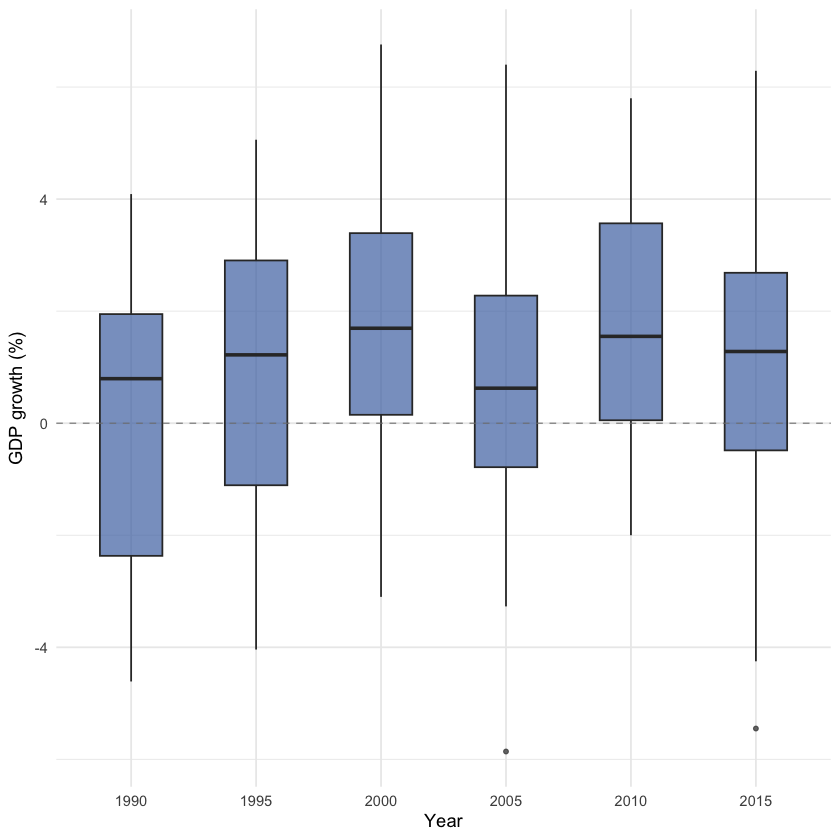

In [3]:
#| label: fig-r-growth-time
#| fig-cap: Distribution of GDP per capita growth rates by period (R).
p1 <- ggplot(panel, aes(x = year_factor, y = gdp_growth)) +
  geom_boxplot(fill = "#4C72B0", alpha = 0.7, width = 0.5, outlier.size = 1) +
  geom_hline(yintercept = 0, color = "gray50", linewidth = 0.3, linetype = "dashed") +
  labs(x = "Year", y = "GDP growth (%)") +
  theme_minimal(base_size = 11)

ggsave("../images/fig-r-growth-time.png", plot = p1, width = 6, height = 4, dpi = 300)
p1

### Convergence: Growth vs. Initial Income

The **convergence hypothesis** predicts that poorer countries grow faster than richer ones, implying a negative slope in the scatter of growth vs. initial income. The blue points are individual country-period observations, and the red line is the OLS fit showing the average relationship.

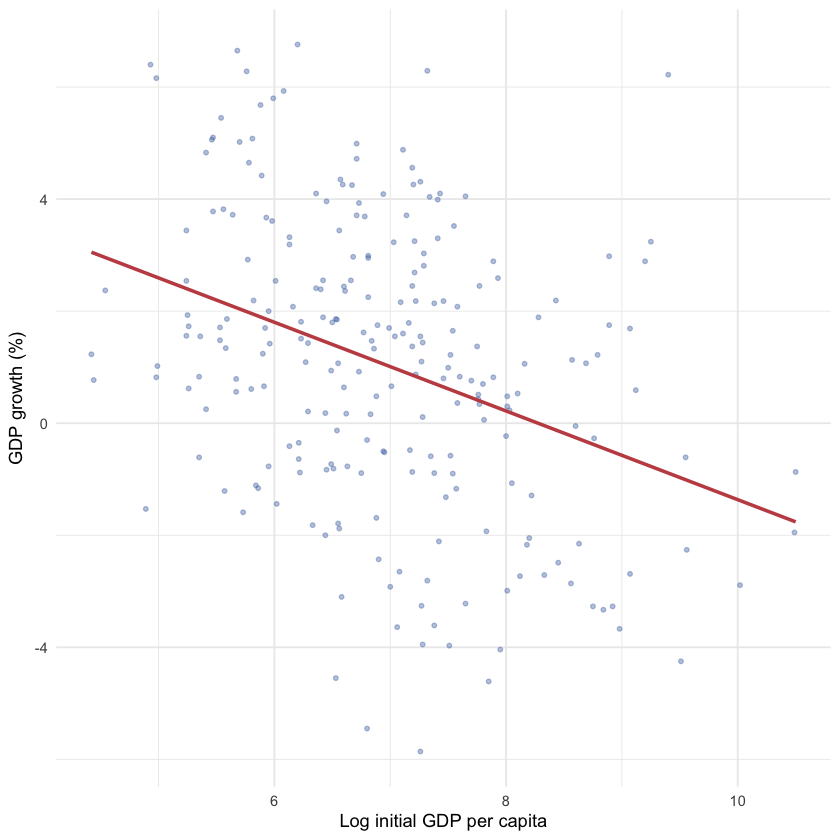

In [4]:
#| label: fig-r-convergence
#| fig-cap: 'Conditional convergence: GDP growth vs. initial income level (R).'
p2 <- ggplot(panel, aes(x = ln_initial_gdp, y = gdp_growth)) +
  geom_point(alpha = 0.4, size = 1, color = "#4C72B0") +
  geom_smooth(method = "lm", se = FALSE, color = "#C44E52", linewidth = 1) +
  labs(x = "Log initial GDP per capita", y = "GDP growth (%)") +
  theme_minimal(base_size = 11)

ggsave("../images/fig-r-convergence.png", plot = p2, width = 6, height = 4, dpi = 300)
p2

### Correlation Matrix

Examining pairwise correlations helps identify which regressors are most associated with growth and whether any regressors are highly correlated with each other (multicollinearity).

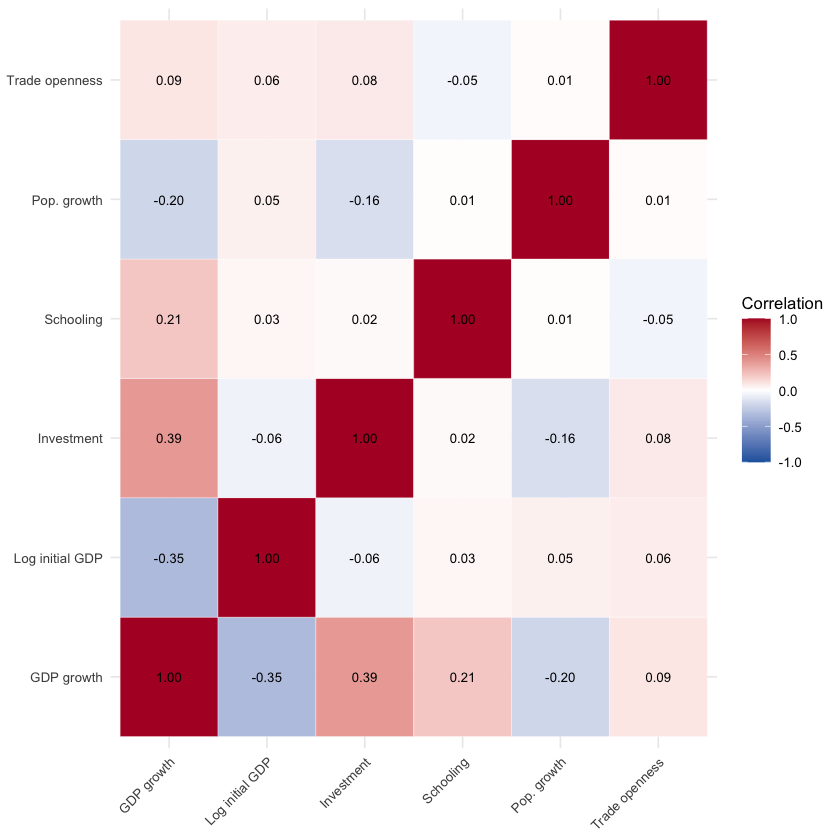

In [5]:
#| label: fig-r-correlation
#| fig-cap: Pairwise correlations between panel variables (R).
# Compute the correlation matrix and assign readable labels
corr <- cor(panel[, vars])
rownames(corr) <- labels
colnames(corr) <- labels

# Reshape the matrix into long format for ggplot
corr_df <- as.data.frame(as.table(corr))
names(corr_df) <- c("Var1", "Var2", "value")

p3 <- ggplot(corr_df, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.2f", value)), size = 2.8) +
  scale_fill_gradient2(
    low = "#2166AC", mid = "white", high = "#B2182B",  # Diverging blue-red palette
    midpoint = 0, limits = c(-1, 1)                     # Centered at zero
  ) +
  labs(x = NULL, y = NULL, fill = "Correlation") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave("../images/fig-r-correlation.png", plot = p3, width = 6, height = 4, dpi = 300)
p3

## 3. Panel Data Regressions

We estimate the growth equation using `fixest::feols()`, which provides efficient estimation of models with high-dimensional fixed effects. The formula syntax uses `|` to separate regressors from absorbed fixed effects.

### Estimation

In [6]:
# (1) Pooled OLS — no fixed effects
#     Treats all observations as independent; ignores the panel structure
#     vcov = ~country clusters standard errors by country
ols <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness,
  data = panel, vcov = ~country
)

# (2) Country FE — absorbs time-invariant country characteristics
#     The "| country" syntax demeans the data within each country
#     fixest auto-clusters SEs by the first FE variable (country)
fe_c <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country,
  data = panel
)

# (3) Time FE — absorbs period-specific global shocks
#     Uses year_factor (not numeric year) so each period gets its own intercept
fe_t <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | year_factor,
  data = panel, vcov = ~country  # Cluster by country, not year
)

# (4) Two-way FE — absorbs both country and time effects
#     The most demanding specification: controls for all unobserved heterogeneity
fe_ct <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country + year_factor,
  data = panel
)

### Build and Export Regression Table

The `etable()` function from `fixest` can export LaTeX tables directly. For Markdown output (used in the manuscript), we build the table manually to ensure proper pipe-delimited format.

In [7]:
# --- Export LaTeX table via etable() ---
etable(ols, fe_c, fe_t, fe_ct, tex = TRUE,
       file = "../tables/tbl-r-regression.tex", replace = TRUE)

# --- Export CSV ---
csv_reg <- etable(ols, fe_c, fe_t, fe_ct)
write.csv(csv_reg, "../tables/tbl-r-regression.csv", row.names = FALSE)

# --- Build Markdown table manually ---
models_list <- list(ols, fe_c, fe_t, fe_ct)
model_names <- c("OLS", "Country FE", "Time FE", "Two-way FE")
varnames <- c("ln_initial_gdp", "investment", "schooling", "pop_growth", "trade_openness")
var_labels_reg <- c("Log initial GDP", "Investment", "Schooling", "Pop. growth", "Trade openness")

# Helper function: format coefficient with significance stars
add_stars <- function(coef_val, pval) {
  s <- ""
  if (pval < 0.01) s <- "***"
  else if (pval < 0.05) s <- "**"
  else if (pval < 0.10) s <- "*"
  paste0(formatC(coef_val, format = "f", digits = 3), s)
}

# Build the header row
col_headers <- paste(sprintf("(%d) %s", 1:4, model_names), collapse = " | ")
md_lines <- c(
  paste0("| | ", col_headers, " |"),
  paste0("|:---|", paste(rep(":---:", 4), collapse = "|"), "|")
)

# Build coefficient + SE rows for each variable
for (i in seq_along(varnames)) {
  coef_row <- var_labels_reg[i]
  se_row <- ""
  for (m in models_list) {
    ct <- coeftable(m)  # Extract the coefficient table (estimates, SEs, p-values)
    if (varnames[i] %in% rownames(ct)) {
      coef_val <- ct[varnames[i], "Estimate"]
      se_val   <- ct[varnames[i], "Std. Error"]
      p_val    <- ct[varnames[i], "Pr(>|t|)"]
      coef_row <- paste0(coef_row, " | ", add_stars(coef_val, p_val))
      se_row   <- paste0(se_row, " | (", formatC(se_val, format = "f", digits = 3), ")")
    } else {
      coef_row <- paste0(coef_row, " | ")
      se_row   <- paste0(se_row, " | ")
    }
  }
  md_lines <- c(md_lines, paste0("| ", coef_row, " |"), paste0("| ", se_row, " |"))
}

# Add separator, FE indicators, and fit statistics
has_country <- c("No", "Yes", "No", "Yes")
has_year    <- c("No", "No", "Yes", "Yes")
n_obs   <- sapply(models_list, function(m) as.character(m$nobs))
r2_vals <- sapply(models_list, function(m) formatC(fitstat(m, "r2")[[1]], format = "f", digits = 3))

md_lines <- c(md_lines,
  "| | | | | |",
  paste0("| Country FE | ", paste(has_country, collapse = " | "), " |"),
  paste0("| Year FE | ", paste(has_year, collapse = " | "), " |"),
  paste0("| Observations | ", paste(n_obs, collapse = " | "), " |"),
  paste0("| R-squared | ", paste(r2_vals, collapse = " | "), " |")
)

md_text <- paste(md_lines, collapse = "\n")
writeLines(md_text, "../tables/tbl-r-regression.md")

# Display the table
IRdisplay::display_markdown(md_text)

```` markdown
---
title: "Example of R Analysis"
jupyter: ir
---

## Overview

This notebook provides a step-by-step introduction to **panel data analysis**
using R. It mirrors the Python analysis (notebook-01) using the same synthetic
Barro-style growth dataset, demonstrating that the same econometric results
can be reproduced across different software environments.

The workflow follows three stages:

1. **Data import** — load the panel dataset and declare its structure
2. **Exploratory data analysis** — descriptive statistics, visualization, and correlation analysis
3. **Fixed effects regression** — estimate growth equations using `fixest`

## 1. Data Import

### Setup

We load the required libraries: `ggplot2` for visualization and `fixest`
for high-dimensional fixed effects estimation. The panel dataset was
generated by the Python notebook and saved as a CSV file.

quarto-executable-code-5450563D

```r
# Load required packages
library(ggplot2)   # Grammar of graphics for visualization
library(fixest)    # Fast fixed effects estimation (feols, etable)

# Set seed for reproducibility
set.seed(42)

# Load the panel dataset generated by the Python notebook
panel <- read.csv("../data/panel_growth.csv")

# Declare panel identifiers as factors (categorical variables)
# This tells R and fixest to treat them as group identifiers, not numbers
panel$country <- as.factor(panel$country)
panel$year_factor <- as.factor(panel$year)

# Verify the panel structure
cat(sprintf("Panel: %d countries × %d periods = %d observations\n",
    length(unique(panel$country)),
    length(unique(panel$year)),
    nrow(panel)))
cat(sprintf("Years: %d–%d\n", min(panel$year), max(panel$year)))
head(panel)
```

## 2. Exploratory Data Analysis

### Descriptive Statistics

Comparing summary statistics at the beginning and end of the sample period
reveals how the distribution of each variable has evolved over time. This
is especially informative for panel data, where time trends and structural
changes are key features.

quarto-executable-code-5450563D

```r
# Define the variables to summarize and their human-readable labels
vars <- c("gdp_growth", "ln_initial_gdp", "investment",
          "schooling", "pop_growth", "trade_openness")
labels <- c("GDP growth", "Log initial GDP", "Investment",
            "Schooling", "Pop. growth", "Trade openness")
years <- c(1990, 2015)  # Initial and final period

# Compute statistics for each variable at each time point
rows <- list()
for (i in seq_along(vars)) {
  for (yr in years) {
    d <- panel[panel$year == yr, vars[i]]  # Subset to one period
    rows[[length(rows) + 1]] <- data.frame(
      Variable = paste0(labels[i], " (", yr, ")"),
      Mean   = round(mean(d), 2),
      Median = round(median(d), 2),
      SD     = round(sd(d), 2),
      IQR    = round(IQR(d), 2),          # Interquartile range (P75 - P25)
      Min    = round(min(d), 2),
      Max    = round(max(d), 2),
      check.names = FALSE
    )
  }
}
desc <- do.call(rbind, rows)  # Combine all rows into one data frame

# Export in three formats: CSV, Markdown, and LaTeX
write.csv(desc, "../tables/tbl-r-descriptive.csv", row.names = FALSE)
md_desc <- paste(knitr::kable(desc, format = "pipe"), collapse = "\n")
writeLines(md_desc, "../tables/tbl-r-descriptive.md")
writeLines(knitr::kable(desc, format = "latex", booktabs = TRUE),
           "../tables/tbl-r-descriptive.tex")

# Display the table as formatted Markdown
IRdisplay::display_markdown(md_desc)
```

### GDP Growth Over Time

Box plots show the distribution of GDP growth rates across 40 countries
within each period. The box spans the interquartile range (IQR), the
horizontal line marks the median, and outliers appear as individual points.
The dashed line at zero separates positive from negative growth.

quarto-executable-code-5450563D

```r
#| label: fig-r-growth-time
#| fig-cap: "Distribution of GDP per capita growth rates by period (R)."

p1 <- ggplot(panel, aes(x = year_factor, y = gdp_growth)) +
  geom_boxplot(fill = "#4C72B0", alpha = 0.7, width = 0.5, outlier.size = 1) +
  geom_hline(yintercept = 0, color = "gray50", linewidth = 0.3, linetype = "dashed") +
  labs(x = "Year", y = "GDP growth (%)") +
  theme_minimal(base_size = 11)

ggsave("../images/fig-r-growth-time.png", plot = p1, width = 6, height = 4, dpi = 300)
p1
```

### Convergence: Growth vs. Initial Income

The **convergence hypothesis** predicts that poorer countries grow faster
than richer ones, implying a negative slope in the scatter of growth vs.
initial income. The blue points are individual country-period observations,
and the red line is the OLS fit showing the average relationship.

quarto-executable-code-5450563D

```r
#| label: fig-r-convergence
#| fig-cap: "Conditional convergence: GDP growth vs. initial income level (R)."

p2 <- ggplot(panel, aes(x = ln_initial_gdp, y = gdp_growth)) +
  geom_point(alpha = 0.4, size = 1, color = "#4C72B0") +
  geom_smooth(method = "lm", se = FALSE, color = "#C44E52", linewidth = 1) +
  labs(x = "Log initial GDP per capita", y = "GDP growth (%)") +
  theme_minimal(base_size = 11)

ggsave("../images/fig-r-convergence.png", plot = p2, width = 6, height = 4, dpi = 300)
p2
```

### Correlation Matrix

Examining pairwise correlations helps identify which regressors are most
associated with growth and whether any regressors are highly correlated
with each other (multicollinearity).

quarto-executable-code-5450563D

```r
#| label: fig-r-correlation
#| fig-cap: "Pairwise correlations between panel variables (R)."

# Compute the correlation matrix and assign readable labels
corr <- cor(panel[, vars])
rownames(corr) <- labels
colnames(corr) <- labels

# Reshape the matrix into long format for ggplot
corr_df <- as.data.frame(as.table(corr))
names(corr_df) <- c("Var1", "Var2", "value")

p3 <- ggplot(corr_df, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.2f", value)), size = 2.8) +
  scale_fill_gradient2(
    low = "#2166AC", mid = "white", high = "#B2182B",  # Diverging blue-red palette
    midpoint = 0, limits = c(-1, 1)                     # Centered at zero
  ) +
  labs(x = NULL, y = NULL, fill = "Correlation") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave("../images/fig-r-correlation.png", plot = p3, width = 6, height = 4, dpi = 300)
p3
```

## 3. Panel Data Regressions

We estimate the growth equation using `fixest::feols()`, which provides
efficient estimation of models with high-dimensional fixed effects. The
formula syntax uses `|` to separate regressors from absorbed fixed effects.

### Estimation

quarto-executable-code-5450563D

```r
# (1) Pooled OLS — no fixed effects
#     Treats all observations as independent; ignores the panel structure
#     vcov = ~country clusters standard errors by country
ols <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness,
  data = panel, vcov = ~country
)

# (2) Country FE — absorbs time-invariant country characteristics
#     The "| country" syntax demeans the data within each country
#     fixest auto-clusters SEs by the first FE variable (country)
fe_c <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country,
  data = panel
)

# (3) Time FE — absorbs period-specific global shocks
#     Uses year_factor (not numeric year) so each period gets its own intercept
fe_t <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | year_factor,
  data = panel, vcov = ~country  # Cluster by country, not year
)

# (4) Two-way FE — absorbs both country and time effects
#     The most demanding specification: controls for all unobserved heterogeneity
fe_ct <- feols(
  gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country + year_factor,
  data = panel
)
```

### Build and Export Regression Table

The `etable()` function from `fixest` can export LaTeX tables directly.
For Markdown output (used in the manuscript), we build the table manually
to ensure proper pipe-delimited format.

quarto-executable-code-5450563D

```r
# --- Export LaTeX table via etable() ---
etable(ols, fe_c, fe_t, fe_ct, tex = TRUE,
       file = "../tables/tbl-r-regression.tex", replace = TRUE)

# --- Export CSV ---
csv_reg <- etable(ols, fe_c, fe_t, fe_ct)
write.csv(csv_reg, "../tables/tbl-r-regression.csv", row.names = FALSE)

# --- Build Markdown table manually ---
models_list <- list(ols, fe_c, fe_t, fe_ct)
model_names <- c("OLS", "Country FE", "Time FE", "Two-way FE")
varnames <- c("ln_initial_gdp", "investment", "schooling", "pop_growth", "trade_openness")
var_labels_reg <- c("Log initial GDP", "Investment", "Schooling", "Pop. growth", "Trade openness")

# Helper function: format coefficient with significance stars
add_stars <- function(coef_val, pval) {
  s <- ""
  if (pval < 0.01) s <- "***"
  else if (pval < 0.05) s <- "**"
  else if (pval < 0.10) s <- "*"
  paste0(formatC(coef_val, format = "f", digits = 3), s)
}

# Build the header row
col_headers <- paste(sprintf("(%d) %s", 1:4, model_names), collapse = " | ")
md_lines <- c(
  paste0("| | ", col_headers, " |"),
  paste0("|:---|", paste(rep(":---:", 4), collapse = "|"), "|")
)

# Build coefficient + SE rows for each variable
for (i in seq_along(varnames)) {
  coef_row <- var_labels_reg[i]
  se_row <- ""
  for (m in models_list) {
    ct <- coeftable(m)  # Extract the coefficient table (estimates, SEs, p-values)
    if (varnames[i] %in% rownames(ct)) {
      coef_val <- ct[varnames[i], "Estimate"]
      se_val   <- ct[varnames[i], "Std. Error"]
      p_val    <- ct[varnames[i], "Pr(>|t|)"]
      coef_row <- paste0(coef_row, " | ", add_stars(coef_val, p_val))
      se_row   <- paste0(se_row, " | (", formatC(se_val, format = "f", digits = 3), ")")
    } else {
      coef_row <- paste0(coef_row, " | ")
      se_row   <- paste0(se_row, " | ")
    }
  }
  md_lines <- c(md_lines, paste0("| ", coef_row, " |"), paste0("| ", se_row, " |"))
}

# Add separator, FE indicators, and fit statistics
has_country <- c("No", "Yes", "No", "Yes")
has_year    <- c("No", "No", "Yes", "Yes")
n_obs   <- sapply(models_list, function(m) as.character(m$nobs))
r2_vals <- sapply(models_list, function(m) formatC(fitstat(m, "r2")[[1]], format = "f", digits = 3))

md_lines <- c(md_lines,
  "| | | | | |",
  paste0("| Country FE | ", paste(has_country, collapse = " | "), " |"),
  paste0("| Year FE | ", paste(has_year, collapse = " | "), " |"),
  paste0("| Observations | ", paste(n_obs, collapse = " | "), " |"),
  paste0("| R-squared | ", paste(r2_vals, collapse = " | "), " |")
)

md_text <- paste(md_lines, collapse = "\n")
writeLines(md_text, "../tables/tbl-r-regression.md")

# Display the table
IRdisplay::display_markdown(md_text)
```
````